In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets"

folders = [

    "california/raw/firms/active_fire",

    "california/processed/fire",

    "california/grids/32x32",

    "california/grids/64x64"
]

for folder in folders:

    os.makedirs(
        os.path.join(BASE, folder),
        exist_ok=True
    )

print("California FIRMS folders created.")

California FIRMS folders created.


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving california_fires.csv to california_fires.csv


In [ ]:
import shutil
import os

BASE = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets"

firms_dir = os.path.join(
    BASE,
    "california/raw/firms/active_fire"
)

SOURCE_FILE = "california_fires.csv"

DEST_FILE = f"{firms_dir}/california_firms_june_2025.csv"

shutil.move(
    SOURCE_FILE,
    DEST_FILE
)

print("California FIRMS CSV moved successfully.")

California FIRMS CSV moved successfully.


In [ ]:
os.listdir(firms_dir)

['california_firms_june_2025.csv']

In [ ]:
import pandas as pd

firms_path = f"{firms_dir}/california_firms_june_2025.csv"

df = pd.read_csv(firms_path)

df.head()

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,37.95030,-122.40009,300.95,0.56,0.52,2025-06-01,926,SNPP,SNPP,n,2,290.14,1.07,N,2
1,36.52149,-119.70261,313.78,0.39,0.44,2025-06-01,926,SNPP,SNPP,n,2,291.52,1.32,N,0
2,36.51744,-119.70329,307.52,0.39,0.44,2025-06-01,926,SNPP,SNPP,n,2,289.38,1.15,N,0
3,35.58593,-119.71248,322.47,0.57,0.43,2025-06-01,926,SNPP,SNPP,n,2,294.34,2.84,N,0
4,34.81968,-118.74982,297.85,0.51,0.41,2025-06-01,927,SNPP,SNPP,n,2,282.54,1.42,N,2


In [ ]:
print(df.columns)

Index(['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date',
       'acq_time', 'satellite', 'instrument', 'confidence', 'version',
       'bright_t31', 'frp', 'daynight', 'type'],
      dtype='object')


In [ ]:
df = df.dropna(
    subset=[
        'latitude',
        'longitude',
        'frp'
    ]
)

In [ ]:
print(df['confidence'].unique()[:20])

['n' 'l' 'h']


In [ ]:
df = df[df['confidence'] != 'low']

In [ ]:
print(
    "Remaining California fire detections:",
    len(df)
)

Remaining California fire detections: 1372


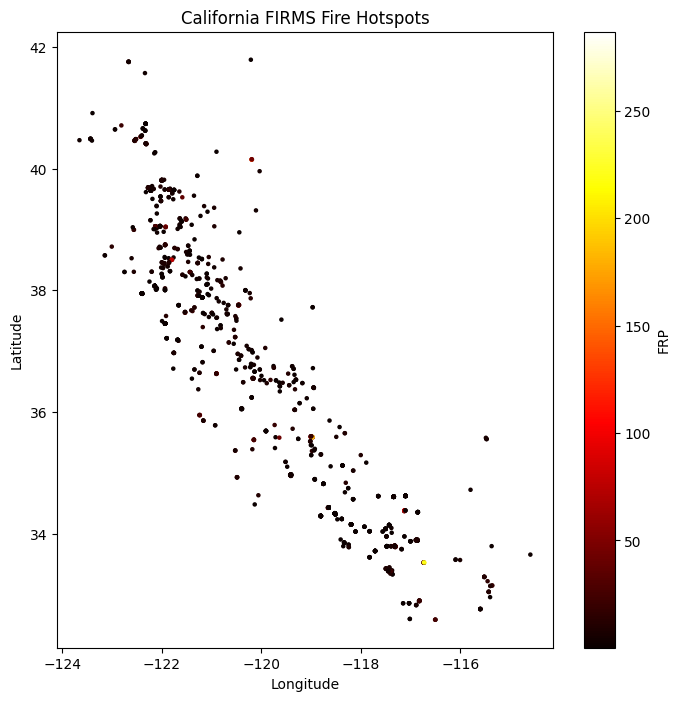

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.scatter(

    df['longitude'],
    df['latitude'],

    s=5,

    c=df['frp'],

    cmap='hot'
)

plt.colorbar(label='FRP')

plt.title("California FIRMS Fire Hotspots")

plt.xlabel("Longitude")

plt.ylabel("Latitude")

plt.show()

In [ ]:
LAT_MIN = 36.5
LAT_MAX = 41.5

LON_MIN = -124.5
LON_MAX = -119.0

In [ ]:
import numpy as np

GRID_SIZE = 32

fire_grid_32 = np.zeros(
    (GRID_SIZE, GRID_SIZE)
)

In [ ]:
for _, row in df.iterrows():

    lat = row['latitude']

    lon = row['longitude']

    frp = row['frp']

    x = int(

        (lon - LON_MIN) /

        (LON_MAX - LON_MIN)

        * (GRID_SIZE - 1)
    )

    y = int(

        (lat - LAT_MIN) /

        (LAT_MAX - LAT_MIN)

        * (GRID_SIZE - 1)
    )

    if 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE:

        fire_grid_32[y, x] += frp

In [ ]:
if fire_grid_32.max() > 0:

    fire_grid_32 = (

        fire_grid_32 /

        fire_grid_32.max()
    )

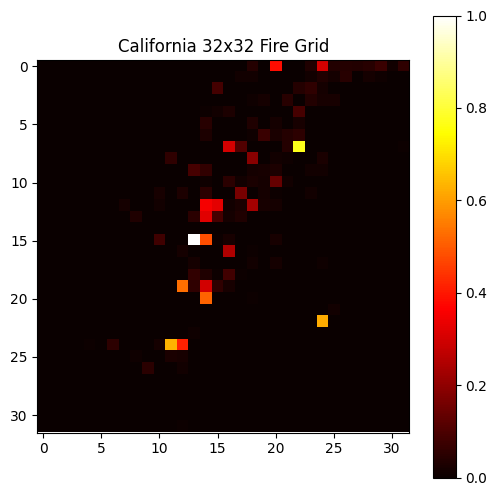

In [ ]:
plt.figure(figsize=(6,6))

plt.imshow(

    fire_grid_32,

    cmap='hot'
)

plt.title("California 32x32 Fire Grid")

plt.colorbar()

plt.show()

In [ ]:
save_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids/32x32/fire.npy"

np.save(
    save_path,
    fire_grid_32
)

print("California 32x32 fire grid saved.")

California 32x32 fire grid saved.


In [ ]:
print(fire_grid_32.shape)

(32, 32)


In [ ]:
GRID_SIZE = 64

fire_grid_64 = np.zeros(
    (GRID_SIZE, GRID_SIZE)
)

In [ ]:
for _, row in df.iterrows():

    lat = row['latitude']

    lon = row['longitude']

    frp = row['frp']

    x = int(

        (lon - LON_MIN) /

        (LON_MAX - LON_MIN)

        * (GRID_SIZE - 1)
    )

    y = int(

        (lat - LAT_MIN) /

        (LAT_MAX - LAT_MIN)

        * (GRID_SIZE - 1)
    )

    if 0 <= x < GRID_SIZE and 0 <= y < GRID_SIZE:

        fire_grid_64[y, x] += frp

In [ ]:
if fire_grid_64.max() > 0:

    fire_grid_64 = (

        fire_grid_64 /

        fire_grid_64.max()
    )

In [ ]:
save_path = "/content/drive/MyDrive/PyroRL_Saudi_Project/datasets/california/grids/64x64/fire.npy"

np.save(
    save_path,
    fire_grid_64
)

print("California 64x64 fire grid saved.")

California 64x64 fire grid saved.
